#Phân tích dữ liệu

Ứng dụng
-Phục vụ cá nhân cải thiện học tập (cực ít)
-Tính năng phụ của e leanring (vấn đề đạo đức)
-Khảo sát để cải thiện e learning (tốt nhất)

In [10]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [11]:
#Tổng thể về Dataset
"""
Link: https://www.kaggle.com/datasets/olgaparfenova/daisee
Bên tạo ra và quản lý: IIIT Hyderabad
Dung Lượng:~15GB
Chủng Tộc - Quốc Gia: Ấn Độ
Định tính video: mỗi video là 10s, luôn có content là 1 học sinh ngồi học, 30fps, 640×480 resolution

"""
#Cấu trúc folder
"""
Folder tổng DAisee

"""

'\nFolder tổng DAisee\n\n'

In [12]:
#Số lượng video
from pathlib import Path
from collections import Counter

BASE_DIR = Path(r"C:\Users\KIET PC\Desktop\Focus_Guard\DAiSEE")
DATASET_DIR = BASE_DIR / "DataSet"

video_extensions = [".avi", ".mp4", ".mov", ".mkv"]

# Đếm theo từng loại đuôi file, và tổng theo từng split con (Train/Validation/Test nếu có)
all_videos = []
for ext in video_extensions:
    all_videos.extend(DATASET_DIR.rglob(f"*{ext}"))

print(f"Tổng số video trong DataSet/: {len(all_videos)}")

# Breakdown theo đuôi file
ext_counter = Counter(v.suffix.lower() for v in all_videos)
print("\nTheo định dạng:")
for ext, count in ext_counter.items():
    print(f"  {ext}: {count}")

# Breakdown theo split con (nếu DataSet chia Train/Validation/Test ở cấp 1)
split_counter = Counter()
for v in all_videos:
    relative = v.relative_to(DATASET_DIR)
    top_folder = relative.parts[0] if len(relative.parts) > 1 else "root"
    split_counter[top_folder] += 1

print("\nTheo thư mục con cấp 1:")
for folder, count in split_counter.items():
    print(f"  {folder}: {count}")

#Số lượng video của train - test- valid
#Số lượng video phân theo giới tính

Tổng số video trong DataSet/: 9068

Theo định dạng:
  .avi: 8232
  .mp4: 836

Theo thư mục con cấp 1:
  Validation: 1720
  Train: 5482
  Test: 1866


In [13]:
#Valid

print("Trai:",5482/9068*100,"%")
print("Test:",1866/9068*100,"%")
print("Valid:",1720/9068*100,"%")

Trai: 60.45434494927216 %
Test: 20.577856197617997 %
Valid: 18.967798853109837 %


Phân tích:
tỷ lệ 60% train là rất thấp, nghĩa là dataset này ưu tiên phân bố cho các công việc testing và benchmark mô hình

In [14]:
#Tỷ lệ giới tính
from pathlib import Path

folder = Path(r"C:\Users\KIET PC\Desktop\Focus_Guard\DAiSEE\GenderClips")
count = {}

for file in folder.iterdir():
    if file.is_file():
        with open(file, "r", encoding="utf-8") as f:
            count[file.stem] = sum(1 for line in f if line.strip())

        print(f"{file.name}: {count[file.stem]} dòng")

print(count)

Females: 2840 dòng
Males: 6228 dòng
{'Females': 2840, 'Males': 6228}


In [15]:
print(type(count))
print(count)

<class 'dict'>
{'Females': 2840, 'Males': 6228}


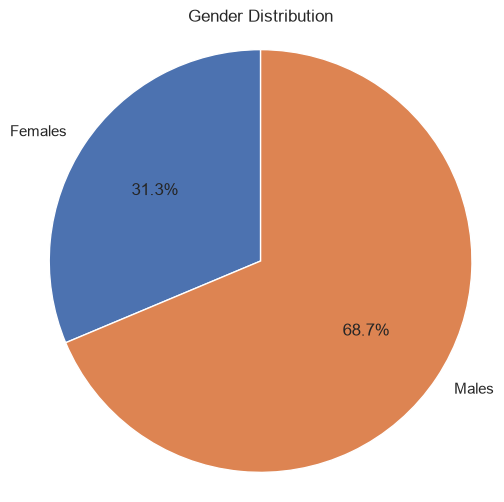

In [16]:
import matplotlib.pyplot as plt

labels = count.keys()
sizes = count.values()

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Gender Distribution")
plt.axis('equal')      # giữ hình tròn
plt.show()

In [17]:
"""
Dataset bị class imbalance
Gender nghiêng về males thì nói lên cái gì, nghĩa là nó sẽ đoán đúng hơn ở male
Vậy có gây ra overfititng không?

"""

'\nDataset bị class imbalance\nGender nghiêng về males thì nói lên cái gì, nghĩa là nó sẽ đoán đúng hơn ở male\nVậy có gây ra overfititng không?\n\n'

In [18]:
import pandas as pd

# Đọc file Excel
df = pd.read_csv(r"C:\Users\KIET PC\Desktop\Focus_Guard\DAiSEE\Labels\AllLabels.csv")

labels = ["Boredom", "Engagement", "Confusion", "Frustration "]

for label in labels:
    print(f"\n========== {label} ==========")

    counts = df[label].value_counts().sort_index()

    # In đủ 0-3 kể cả khi không có
    for level in range(4):
        print(f"Level {level}: {counts.get(level, 0)}")


========== Boredom ==========
Level 0: 3822
Level 1: 2850
Level 2: 1923
Level 3: 330

========== Engagement ==========
Level 0: 61
Level 1: 455
Level 2: 4422
Level 3: 3987

========== Confusion ==========
Level 0: 5951
Level 1: 2133
Level 2: 741
Level 3: 100

========== Frustration  ==========
Level 0: 6887
Level 1: 1613
Level 2: 338
Level 3: 87


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/eda_class_distribution.png'

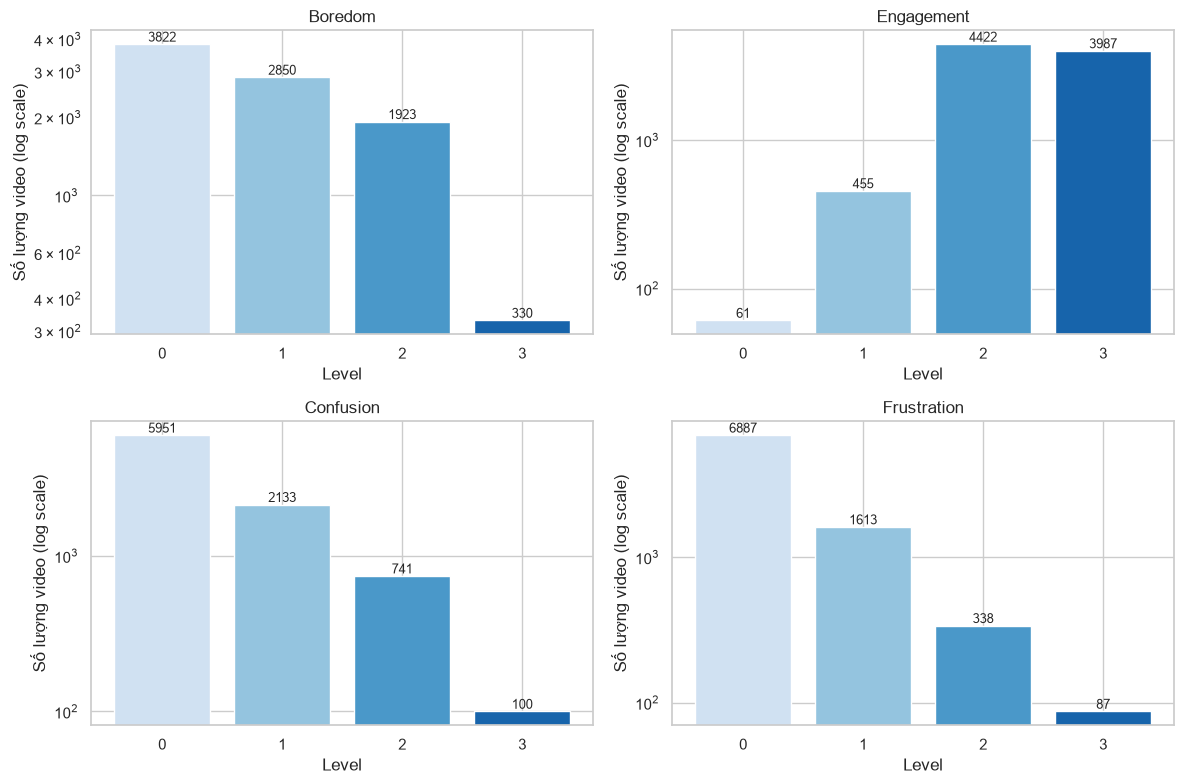

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "Boredom":     [3822, 2850, 1923, 330],
    "Engagement":  [61, 455, 4422, 3987],
    "Confusion":   [5951, 2133, 741, 100],
    "Frustration": [6887, 1613, 338, 87],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (label, counts) in enumerate(data.items()):
    axes[i].bar(range(4), counts, color=sns.color_palette("Blues", 4))
    axes[i].set_title(label)
    axes[i].set_xlabel("Level")
    axes[i].set_ylabel("Số lượng video (log scale)")
    axes[i].set_yscale("log")  # quan trọng — mới thấy rõ cột nhỏ
    axes[i].set_xticks(range(4))
    for j, v in enumerate(counts):
        axes[i].text(j, v, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/eda_class_distribution.png", dpi=150)
plt.show()

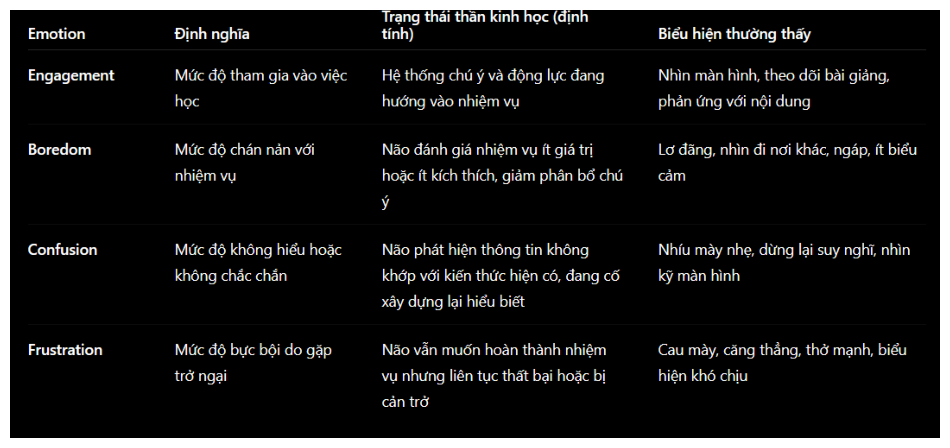

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(r"C:\Users\KIET PC\Desktop\Focus_Guard\Screenshot 2026-08-08 004155.png")
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

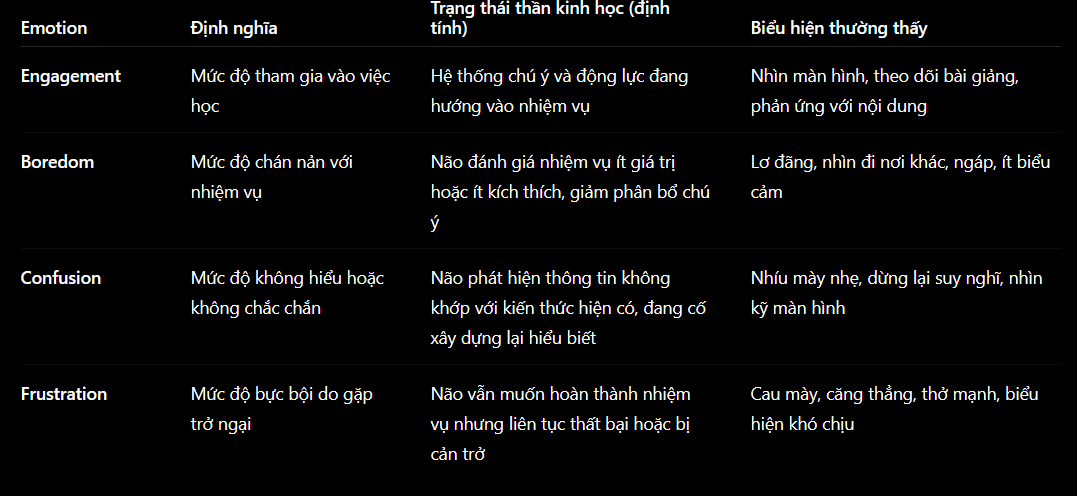

Mức độ imbalanced cao, rất khó để detect đúng sai
Boredom rất nhiều ở 0 1 và 2, nhưng ko có ở 3, nghĩa là không có ai tới mức này
Boredom mức 3 thường là không thấy có động lực, phần thưởng cao, Pre Frontal Cortex hoạt động yếu
Tuy nhiên mức 3 cao nghĩa là vẫn có phần lớn đang cảm thấy chán

Frustration và Confusion cực cao ở level 0, nghĩa là cường độ khó hiểu và frustration ở mức thấp, có thể là do học sinh này tốt hoặc bài giảng đc thiết kế tốt

Engagemant tập trung nhiều ở cường độ cao, có thể do lý do như trên hoc jsinh tập trung cao do bài giảng tốt và có thể những level thấp hơn của engamenet có thể bị điểm sai
+Các video được thu thập khi người học vẫn đang chủ động theo dõi bài học, dẫn đến mức Engagement nhìn chung cao.
+Người gán nhãn có xu hướng đánh giá các hành vi nhìn màn hình, duy trì tư thế học tập là mức Engagement cao.
+Cũng không loại trừ khả năng tồn tại annotation bias, khiến các mức Engagement thấp bị gán ít hơn thực tế.

In [ ]:
M